In [1]:
import sys
sys.path.insert(0, '..')
from dependencies import *

envelopes_log = eelbrain.load.unpickle(PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
subject_model_predictors = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')
durations = get_durations(envelopes_log)
models = get_models(exclude=['envelope_log_8band'])

In [2]:
# -----------------------------
# Load TRFs (h NDVars)
# -----------------------------
encoder_log_trf = []
encoder_onset_trf = []
decoder_log_trf = []
decoder_onset_trf = []

universal_encoder_log_trf = eelbrain.load.unpickle(TRF_DIR / f'universal-trf-envelope_log.pickle')
universal_encoder_onset_trf = eelbrain.load.unpickle(TRF_DIR / f'universal-trf-envelope_onset.pickle')

for subject in SUBJECTS:
    encoder_log_trf.append(eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} envelope_log.pickle').h)
    encoder_onset_trf.append(eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} envelope_onset.pickle').h)
    decoder_log_trf.append(eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} decoder-envelope_log.pickle').h)
    decoder_onset_trf.append(eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} decoder-envelope_onset.pickle').h)

# Configure matplotlib style
FONT = 'Arial'
FONT_SIZE = 8
RC = {
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.transparent': True,
    'font.family': 'sans-serif',
    'font.sans-serif': FONT,
    'font.size': FONT_SIZE,
    'figure.labelsize': FONT_SIZE,
    'figure.titlesize': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,    
    'legend.fontsize': FONT_SIZE,
}
plt.rcParams.update(RC)

# --- Parameters ---
times = [0.04, 0.14, 0.24]
times_log = [0.04, 0.14, 0.24]
times_onset = [0.05, 0.2, 0.32]
time_labels = ['%d ms' % (t*1000) for t in times_log]

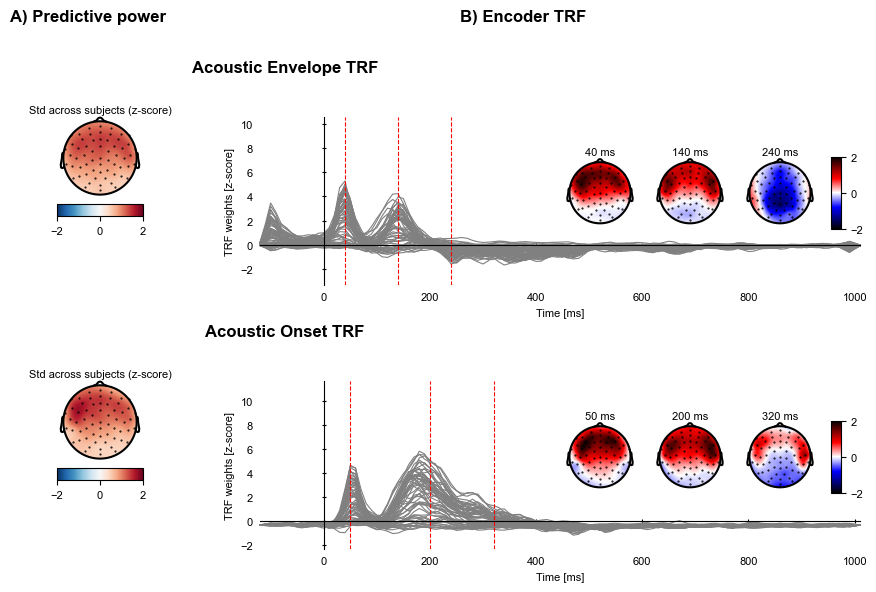

In [4]:
import matplotlib.pyplot as plt
import eelbrain
import numpy as np

# ------------------------------------------------
# Encoder TRFs and subject lists
# ------------------------------------------------
encoder_trfs = {
    'log': universal_encoder_log_trf,
    'onset': universal_encoder_onset_trf
}

all_subjects_dict = {
    'log': encoder_log_trf,
    'onset': encoder_onset_trf
}

times_dict = {
    'log': times_log,
    'onset': times_onset
}

# ------------------------------------------------
# Compute variability across subjects
# ------------------------------------------------
variability_maps = {}
mean_trfs = {}
for trf_type in ['log', 'onset']:
    subjects = all_subjects_dict[trf_type]
    subject_ndvars = []
    for sub in subjects:
        if isinstance(sub, eelbrain.NDVar):
            subject_ndvars.append(sub)
        elif isinstance(sub, tuple):
            subject_ndvars.append(sub[0])
        else:
            raise ValueError(f"Unexpected subject type: {type(sub)}")
    stacked = eelbrain.combine(subject_ndvars)
    
    # Compute mean and std across subjects
    mean_ndvar = stacked.mean('case')
    std_ndvar = stacked.std('case')
    
    # Z-score normalization
    z_mean = (mean_ndvar - mean_ndvar.mean()) / std_ndvar.mean()  # normalize by overall mean/std
    z_std = std_ndvar / std_ndvar.mean()
    
    mean_trfs[trf_type] = z_mean
    variability_maps[trf_type] = z_std

# ------------------------------------------------
# Figure setup
# ------------------------------------------------
fig = plt.figure(figsize=(10, 6))

# Panel labels
fig.text(0.05, 0.96, 'A) Predictive power', fontsize=12, fontweight='bold')
fig.text(0.50, 0.96, 'B) Encoder TRF', fontsize=12, fontweight='bold')

# Layout parameters
left_col = 0.05
right_col = 0.30
row_height = 0.40
gap_row = 0.04
width_var = 0.18
width_butterfly = 0.60
height_topo = 0.12
width_topo = 0.10
gap_topo = 0.005  # decreased space between topomaps

# ------------------------------------------------
# Loop over models
# ------------------------------------------------
for row_idx, trf_type in enumerate(['log', 'onset']):
    trf = mean_trfs[trf_type]             # already z-scored
    times = times_dict[trf_type]
    var_ndvar = variability_maps[trf_type]  # already normalized

    # Vertical position for this row
    bottom_row = 0.52 - row_idx*(row_height + gap_row)

    # ---------------------
    # Row-level title (centered above both left and right)
    # ---------------------
    left_edge = left_col
    right_edge = right_col + width_butterfly
    type_model = f'Acoustic Envelope' if trf_type == 'log' else f'Acoustic Onset'
    fig.text((left_edge + right_edge)/2 -0.15, bottom_row + row_height - 0.05,
             f'{type_model} TRF', fontsize=12, fontweight='bold',
             ha='center', va='bottom')

    # ---------------------
    # Variability topomap (left)
    # ---------------------
    ax_var = fig.add_axes([left_col, bottom_row + (row_height - height_topo)/2, width_var, height_topo*1.2])
    eelbrain.plot.Topomap(
        var_ndvar,
        axes=ax_var,
        axtitle='Std across subjects (z-score)',
        cmap='RdBu_r',
        clip='circle',
        vmax=None
    )
    # Colorbar
    im_var = ax_var.get_images()[0]
    cbar_ax = fig.add_axes([
        ax_var.get_position().x0,
        ax_var.get_position().y0 - 0.025,
        ax_var.get_position().width,
        0.02
    ])
    fig.colorbar(im_var, cax=cbar_ax, orientation='horizontal')

    # ---------------------
    # Butterfly TRF (right)
    # ---------------------
    ax_butterfly = fig.add_axes([right_col, bottom_row, width_butterfly, row_height*0.7])
    eelbrain.plot.Butterfly(
        trf,
        axes=ax_butterfly,
        linewidth=0.8,
        color='0.5',
        ylabel='TRF weights [z-score]',
        frame='t'
    )
    ax_butterfly.set_xlim(trf.time[0], trf.time[-1])
    y_lim = [trf.x.min(), trf.x.max()]
    ax_butterfly.set_ylim(y_lim[0]*2, y_lim[1]*2)

    # Add vertical red lines for the latency times
    for t in times:
        ax_butterfly.axvline(t, color='r', linestyle='--', linewidth=0.8)

    # ---------------------
    # Latency topomaps (top-right, above butterfly)
    # ---------------------
    n_topos = len(times)
    butterfly_pos = ax_butterfly.get_position()
    bottom_topos = butterfly_pos.y0 + 0.3*butterfly_pos.height + 0.01
    left_start = butterfly_pos.x0 + butterfly_pos.width - (n_topos*width_topo + (n_topos-1)*gap_topo)

    topomap_axes = []
    for i, t in enumerate(times):
        ax_topo = fig.add_axes([
            left_start + i*(width_topo + gap_topo) - i*0.015,
            bottom_topos,
            width_topo,
            height_topo
        ])
        topo_trf = trf.sub(time=t)
        eelbrain.plot.Topomap(
            topo_trf,
            axes=ax_topo,
            axtitle=f"{int(t*1000)} ms",
            clip='circle',
            vmax=None
        )
        topomap_axes.append(ax_topo)

    # ---------------------
    # Add vertical colorbar to the right of the topomaps
    # ---------------------
    im_topo = topomap_axes[-1].get_images()[0]
    pos = topomap_axes[-1].get_position()
    cbar_ax = fig.add_axes([
        pos.x0 + pos.width + 0.015,  # just to the right
        bottom_topos,
        0.01,                        # vertical bar width
        height_topo                    # same height as topomaps
    ])
    fig.colorbar(im_topo, cax=cbar_ax, orientation='vertical')

plt.show()


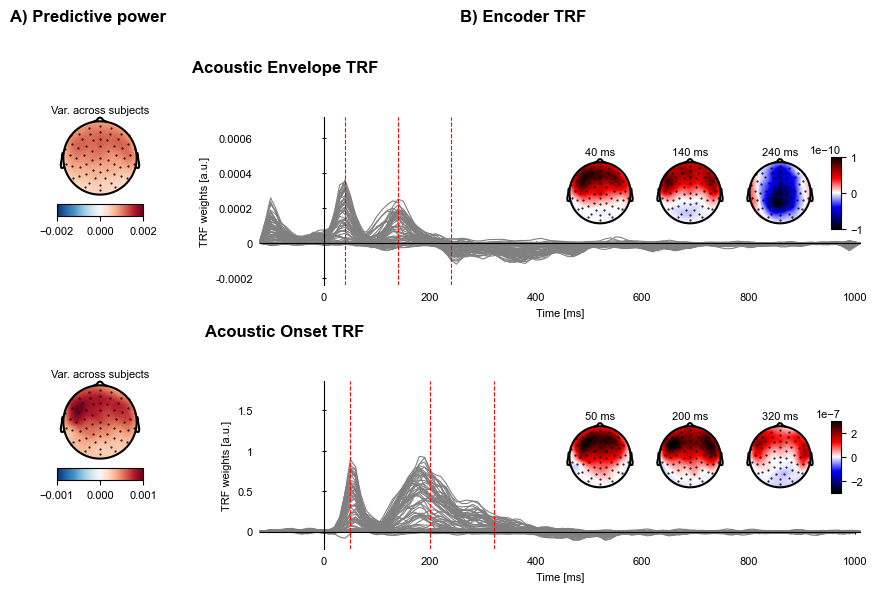

In [109]:
import matplotlib.pyplot as plt
import eelbrain
import numpy as np

# ------------------------------------------------
# Encoder TRFs and subject lists
# ------------------------------------------------
encoder_trfs = {
    'log': universal_encoder_log_trf,
    'onset': universal_encoder_onset_trf
}

all_subjects_dict = {
    'log': encoder_log_trf,
    'onset': encoder_onset_trf
}

times_dict = {
    'log': times_log,
    'onset': times_onset
}

# ------------------------------------------------
# Compute variability across subjects
# ------------------------------------------------
variability_maps = {}
for trf_type in ['log', 'onset']:
    subjects = all_subjects_dict[trf_type]
    subject_ndvars = []
    for sub in subjects:
        if isinstance(sub, eelbrain.NDVar):
            subject_ndvars.append(sub)
        elif isinstance(sub, tuple):
            subject_ndvars.append(sub[0])
        else:
            raise ValueError(f"Unexpected subject type: {type(sub)}")
    stacked = eelbrain.combine(subject_ndvars)
    variability_maps[trf_type] = stacked.std('case')

# ------------------------------------------------
# Figure setup
# ------------------------------------------------
fig = plt.figure(figsize=(10, 6))

# Panel labels
fig.text(0.05, 0.96, 'A) Predictive power', fontsize=12, fontweight='bold')
fig.text(0.50, 0.96, 'B) Encoder TRF', fontsize=12, fontweight='bold')

# Layout parameters
left_col = 0.05
right_col = 0.30
row_height = 0.40
gap_row = 0.04
width_var = 0.18
width_butterfly = 0.60
height_topo = 0.12
width_topo = 0.10
gap_topo = 0.005  # decreased space between topomaps

# ------------------------------------------------
# Loop over models
# ------------------------------------------------
for row_idx, trf_type in enumerate(['log', 'onset']):
    trf = encoder_trfs[trf_type]
    times = times_dict[trf_type]
    var_ndvar = variability_maps[trf_type]

    # Vertical position for this row
    bottom_row = 0.52 - row_idx*(row_height + gap_row)

    # ---------------------
    # Row-level title (centered above both left and right)
    # ---------------------
    left_edge = left_col
    right_edge = right_col + width_butterfly
    type_model = f'Acoustic Envelope' if trf_type == 'log' else f'Acoustic Onset'
    fig.text((left_edge + right_edge)/2 -0.15, bottom_row + row_height - 0.05,
             f'{type_model} TRF', fontsize=12, fontweight='bold',
             ha='center', va='bottom')

    # ---------------------
    # Variability topomap (left)
    # ---------------------
    ax_var = fig.add_axes([left_col, bottom_row + (row_height - height_topo)/2, width_var, height_topo*1.2])
    eelbrain.plot.Topomap(
        var_ndvar,
        axes=ax_var,
        axtitle='Var. across subjects',
        cmap='RdBu_r',
        clip='circle',
        vmax=None
    )
    # Colorbar
    im_var = ax_var.get_images()[0]
    cbar_ax = fig.add_axes([
        ax_var.get_position().x0,
        ax_var.get_position().y0 - 0.025,
        ax_var.get_position().width,
        0.02
    ])
    fig.colorbar(im_var, cax=cbar_ax, orientation='horizontal')

    # ---------------------
    # Butterfly TRF (right)
    # ---------------------
    ax_butterfly = fig.add_axes([right_col, bottom_row, width_butterfly, row_height*0.7])
    eelbrain.plot.Butterfly(
        trf,
        axes=ax_butterfly,
        linewidth=0.8,
        color='0.5',
        ylabel='TRF weights [a.u.]',
        frame='t'
    )
    ax_butterfly.set_xlim(trf.time[0], trf.time[-1])
    y_lim = [trf.x.min(), trf.x.max()]
    ax_butterfly.set_ylim(y_lim[0]*2, y_lim[1]*2)

    # Add vertical red lines for the latency times
    for t in times:
        ax_butterfly.axvline(t, color='r', linestyle='--', linewidth=0.8)

    # ---------------------
    # Latency topomaps (top-right, above butterfly)
    # ---------------------
    n_topos = len(times)
    butterfly_pos = ax_butterfly.get_position()
    bottom_topos = butterfly_pos.y0 + 0.3*butterfly_pos.height + 0.01
    left_start = butterfly_pos.x0 + butterfly_pos.width - (n_topos*width_topo + (n_topos-1)*gap_topo)

    topomap_axes = []
    for i, t in enumerate(times):
        ax_topo = fig.add_axes([
            left_start + i*(width_topo + gap_topo) - i*0.015,
            bottom_topos,
            width_topo,
            height_topo
        ])
        topo_trf = trf.sub(time=t)
        eelbrain.plot.Topomap(
            topo_trf,
            axes=ax_topo,
            axtitle=f"{int(t*1000)} ms",
            clip='circle',
            vmax=None
        )
        topomap_axes.append(ax_topo)

    # ---------------------
    # Add vertical colorbar to the right of the topomaps
    # ---------------------
    im_topo = topomap_axes[-1].get_images()[0]
    pos = topomap_axes[-1].get_position()
    cbar_ax = fig.add_axes([
        pos.x0 + pos.width + 0.015,  # just to the right
        bottom_topos,
        0.01,                        # vertical bar width
        height_topo                    # same height as topomaps
    ])
    fig.colorbar(im_topo, cax=cbar_ax, orientation='vertical')

plt.show()




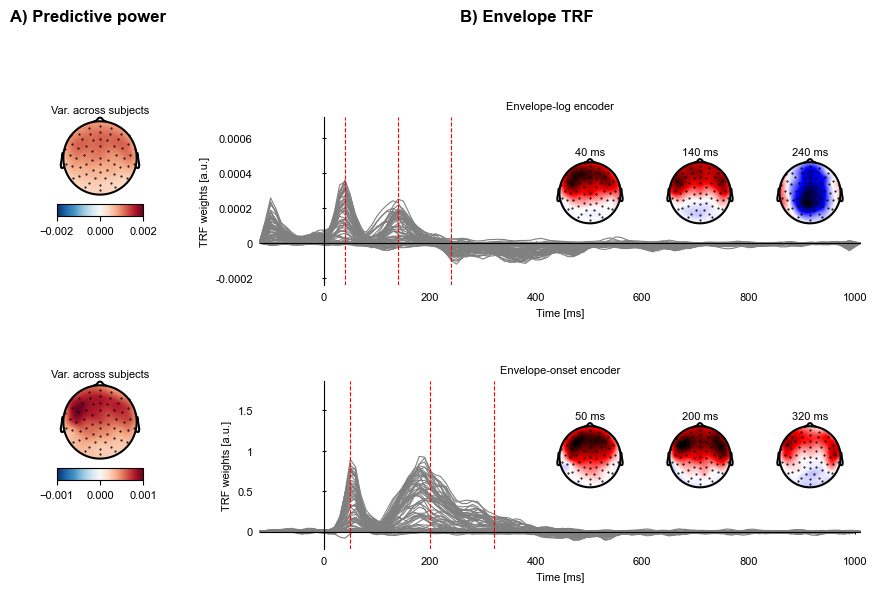

In [78]:
import matplotlib.pyplot as plt
import eelbrain
import numpy as np

# ------------------------------------------------
# Encoder TRFs and subject lists
# ------------------------------------------------
encoder_trfs = {
    'log': universal_encoder_log_trf,
    'onset': universal_encoder_onset_trf
}

all_subjects_dict = {
    'log': encoder_log_trf,
    'onset': encoder_onset_trf
}

times_dict = {
    'log': times_log,
    'onset': times_onset
}

# ------------------------------------------------
# Compute variability across subjects
# ------------------------------------------------
variability_maps = {}
for trf_type in ['log', 'onset']:
    subjects = all_subjects_dict[trf_type]
    subject_ndvars = []
    for sub in subjects:
        if isinstance(sub, eelbrain.NDVar):
            subject_ndvars.append(sub)
        elif isinstance(sub, tuple):
            subject_ndvars.append(sub[0])
        else:
            raise ValueError(f"Unexpected subject type: {type(sub)}")
    stacked = eelbrain.combine(subject_ndvars)
    variability_maps[trf_type] = stacked.std('case')

# ------------------------------------------------
# Figure setup
# ------------------------------------------------
fig = plt.figure(figsize=(10, 6))

# Panel labels
fig.text(0.05, 0.96, 'A) Predictive power', fontsize=12, fontweight='bold')
fig.text(0.50, 0.96, 'B) Envelope TRF', fontsize=12, fontweight='bold')

# Layout parameters
left_col = 0.05
right_col = 0.30
row_height = 0.40
gap_row = 0.04
width_var = 0.18
width_butterfly = 0.60
height_topo = 0.12   # smaller than before
width_topo = 0.10
gap_topo = 0.01

# ------------------------------------------------
# Loop over models
# ------------------------------------------------
for row_idx, trf_type in enumerate(['log', 'onset']):
    trf = encoder_trfs[trf_type]
    times = times_dict[trf_type]
    var_ndvar = variability_maps[trf_type]

    # Vertical position for this row
    bottom_row = 0.52 - row_idx*(row_height + gap_row)

    # ---------------------
    # Variability topomap (left)
    # ---------------------
    ax_var = fig.add_axes([left_col, bottom_row + (row_height - height_topo)/2, width_var, height_topo*1.2])
    eelbrain.plot.Topomap(
        var_ndvar,
        axes=ax_var,
        axtitle='Var. across subjects',
        cmap='RdBu_r',
        clip='circle',
        vmax=None
    )
    # Colorbar
    im_var = ax_var.get_images()[0]
    cbar_ax = fig.add_axes([
        ax_var.get_position().x0,
        ax_var.get_position().y0 - 0.025,
        ax_var.get_position().width,
        0.02
    ])
    fig.colorbar(im_var, cax=cbar_ax, orientation='horizontal')

    # ---------------------
    # Butterfly TRF (right)
    # ---------------------
    ax_butterfly = fig.add_axes([right_col, bottom_row, width_butterfly, row_height*0.7])
    eelbrain.plot.Butterfly(
        trf,
        axes=ax_butterfly,
        linewidth=0.8,
        color='0.5',
        ylabel='TRF weights [a.u.]',
        frame='t'
    )
    ax_butterfly.set_title(f'Envelope-{trf_type} encoder')
    ax_butterfly.set_xlim(trf.time[0], trf.time[-1])
    y_lim = [trf.x.min(), trf.x.max()]
    ax_butterfly.set_ylim(y_lim[0]*2, y_lim[1]*2)

    # Add vertical red lines for the latency times
    for t in times:
        ax_butterfly.axvline(t, color='r', linestyle='--', linewidth=0.8)

    # ---------------------
    # Latency topomaps (top-right, above butterfly)
    # ---------------------
    n_topos = len(times)
    butterfly_pos = ax_butterfly.get_position()
    bottom_topos = butterfly_pos.y0 + 0.3*butterfly_pos.height + 0.01
    left_start = butterfly_pos.x0 + butterfly_pos.width - (n_topos*width_topo + (n_topos-1)*gap_topo)

    for i, t in enumerate(times):
        ax_topo = fig.add_axes([
            left_start + i*(width_topo + gap_topo),
            bottom_topos,
            width_topo,
            height_topo
        ])
        topo_trf = trf.sub(time=t)
        eelbrain.plot.Topomap(
            topo_trf,
            axes=ax_topo,
            axtitle=f"{int(t*1000)} ms",
            clip='circle',
            vmax=None
        )

plt.show()



/var/folders/y0/p95jrf3s35b2tqj_rnj24xjr0000gn/T/ipykernel_60836/1649969314.py:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


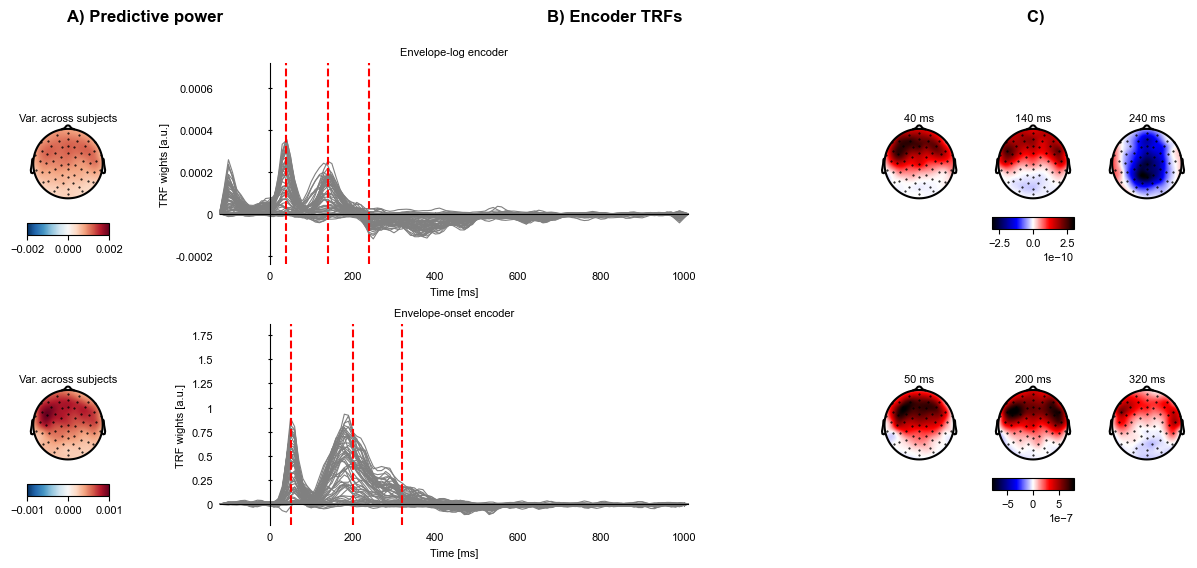

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import eelbrain

# ------------------------------------------------
# Encoder TRFs
# ------------------------------------------------
encoder_trfs = {
    'log': universal_encoder_log_trf,
    'onset': universal_encoder_onset_trf
}

all_subjects_dict = {
    'log': encoder_log_trf,    # list of per-subject NDVars
    'onset': encoder_onset_trf
}

times_dict = {
    'log': times_log,
    'onset': times_onset
}

# ------------------------------------------------
# Compute variability across subjects
# ------------------------------------------------
variability_maps = {}

for trf_type in ['log', 'onset']:
    subjects = all_subjects_dict[trf_type]

    # Extract NDVars (if stored as tuple or NDVar)
    subject_ndvars = []
    for sub in subjects:
        if isinstance(sub, eelbrain.NDVar):
            subject_ndvars.append(sub)
        elif isinstance(sub, tuple):  # e.g., if saved as (NDVar,)
            subject_ndvars.append(sub[0])
        else:
            raise ValueError(f"Unexpected subject type: {type(sub)}")

    # Combine across subjects (adds 'case' dim)
    stacked = eelbrain.combine(subject_ndvars)

    # Variability across subjects (standard deviation along 'case')
    variability = stacked.std('case')

    # Save NDVar for plotting
    variability_maps[trf_type] = variability

# ------------------------------------------------
# Plotting
# ------------------------------------------------
fig = plt.figure(figsize=(16, 6))

gs = fig.add_gridspec(
    2, 5,
    width_ratios=[0.7, 4.0, 0.7, 0.7, 0.7],
    wspace=0.7,
    hspace=0.3
)

# Panel labels
fig.text(0.15, 0.95, 'A) Predictive power', fontsize=12, fontweight='bold')
fig.text(0.45, 0.95, 'B) Encoder TRFs', fontsize=12, fontweight='bold')
fig.text(0.75, 0.95, 'C) ', fontsize=12, fontweight='bold')

# ------------------------------------------------
# Main plotting loop
# ------------------------------------------------
for row, trf_type in enumerate(['log', 'onset']):
    trf = encoder_trfs[trf_type]
    times = times_dict[trf_type]

    # ---------------------
    # Variability Topomap (left)
    # ---------------------
    var_ndvar = variability_maps[trf_type]

    ax_var = fig.add_subplot(gs[row, 0])
    topo_var = eelbrain.plot.Topomap(
        var_ndvar,
        axes=ax_var,
        axtitle='Var. across subjects',
        cmap='RdBu_r',
        clip='circle',
        vmax=None
    )

    im_var = ax_var.get_images()[0]
    cbar_ax = fig.add_axes([
        ax_var.get_position().x0,
        ax_var.get_position().y0 - 0.05,
        ax_var.get_position().width,
        0.02
    ])
    fig.colorbar(im_var, cax=cbar_ax, orientation='horizontal')

    # ---------------------
    # Butterfly plot (center)
    # ---------------------
    ax_butterfly = fig.add_subplot(gs[row, 1])
    eelbrain.plot.Butterfly(
        trf,
        axes=ax_butterfly,
        linewidth=0.8,
        color='0.5',
        ylabel='TRF wights [a.u.]',
        frame='t'
    )

    for t in times:
        ax_butterfly.axvline(t, color='r', linestyle='--')

    ax_butterfly.set_title(f'Envelope-{trf_type} encoder')
    ax_butterfly.set_xlim(trf.time[0], trf.time[-1])

    # Stretch y-axis to make waves more “wavey”
    scaling = 2
    y_lim = [trf.min()*scaling, trf.max()*scaling]
    ax_butterfly.set_ylim(y_lim[0], y_lim[1])

    # ---------------------
    # Latency topomaps (right)
    # ---------------------
    topomap_axes = []
    mappables = []

    for i, t in enumerate(times):
        ax_topo = fig.add_subplot(gs[row, i+2])
        topo_trf = trf.sub(time=t)
        topo_plot = eelbrain.plot.Topomap(
            topo_trf,
            axes=ax_topo,
            axtitle=f"{int(t*1000)} ms",
            clip='circle',
            vmax=None
        )
        im_topo = ax_topo.get_images()[0]
        topomap_axes.append(ax_topo)
        mappables.append(im_topo)

    # Tighten spacing between the three topomaps
    positions = [ax.get_position() for ax in topomap_axes]
    total_width = sum([pos.width for pos in positions]) + 0.02*2
    center_x = (positions[0].x0 + positions[-1].x0 + positions[-1].width) / 2
    start_x = center_x - total_width / 2
    gap = 0.02
    for i, ax in enumerate(topomap_axes):
        pos = ax.get_position()
        ax.set_position([
            start_x + i*(pos.width + gap),
            pos.y0,
            pos.width,
            pos.height
        ])

    # Single horizontal colorbar under middle topomap
    middle_ax = topomap_axes[1]
    im_middle = mappables[1]
    cbar_ax = fig.add_axes([
        middle_ax.get_position().x0,
        middle_ax.get_position().y0 - 0.04,
        middle_ax.get_position().width,
        0.02
    ])
    fig.colorbar(im_middle, cax=cbar_ax, orientation='horizontal')

plt.tight_layout()
plt.show()


/var/folders/y0/p95jrf3s35b2tqj_rnj24xjr0000gn/T/ipykernel_60836/1021138572.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


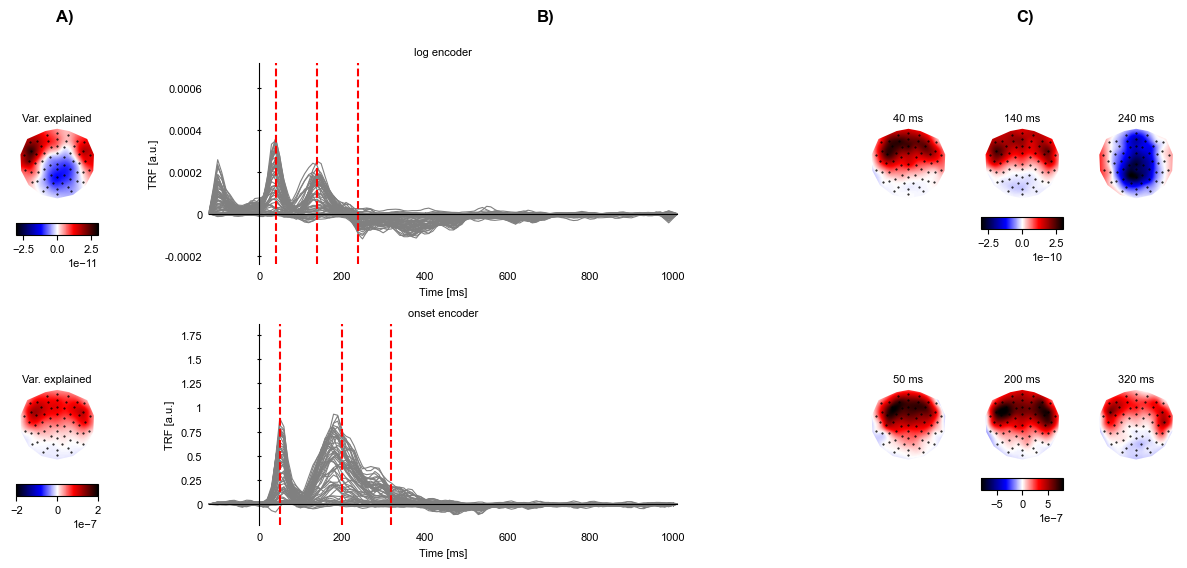

In [25]:
# --- Encoder TRFs ---
encoder_trfs = {
    'log': universal_encoder_log_trf,
    'onset': universal_encoder_onset_trf
}

times_dict = {
    'log': times_log,
    'onset': times_onset
}

fig = plt.figure(figsize=(16, 6))  # wide figure

gs = fig.add_gridspec(
    2, 5,
    width_ratios=[0.7, 4.0, 0.7, 0.7, 0.7],
    wspace=0.7,
    hspace=0.3
)

# Panel labels
fig.text(0.15, 0.95, 'A)', fontsize=12, fontweight='bold')
fig.text(0.45, 0.95, 'B)', fontsize=12, fontweight='bold')
fig.text(0.75, 0.95, 'C)', fontsize=12, fontweight='bold')

for row, trf_type in enumerate(['log', 'onset']):
    trf = encoder_trfs[trf_type]
    times = times_dict[trf_type]

    # ---------------------
    # Variability Explained Topomap (left)
    # ---------------------
    var_exp_trf = trf.mean('time')
    ax_var = fig.add_subplot(gs[row, 0])
    topo_var = eelbrain.plot.Topomap(var_exp_trf, axes=ax_var, axtitle='Var. explained', vmax=None)
    im_var = ax_var.get_images()[0]
    cbar_ax = fig.add_axes([ax_var.get_position().x0,
                            ax_var.get_position().y0 - 0.05,
                            ax_var.get_position().width, 0.02])
    fig.colorbar(im_var, cax=cbar_ax, orientation='horizontal')

    # ---------------------
    # Butterfly plot (center)
    # ---------------------
    ax_butterfly = fig.add_subplot(gs[row, 1])
    eelbrain.plot.Butterfly(trf, axes=ax_butterfly,
                            linewidth=0.8, color='0.5', ylabel='TRF [a.u.]', frame='t')
    for t in times:
        ax_butterfly.axvline(t, color='r', linestyle='--')
    ax_butterfly.set_title(f'{trf_type} encoder')
    ax_butterfly.set_xlim(trf.time[0], trf.time[-1])

    # Stretch y-axis to make waves more “wavey”
    y_lim = [trf.min(), trf.max()]
    ax_butterfly.set_ylim(y_lim[0]*2, y_lim[1]*2)

    # ---------------------
    # Topomap plots for latencies (right)
    # ---------------------
    topomap_axes = []
    mappables = []
    for i, t in enumerate(times):
        ax_topo = fig.add_subplot(gs[row, i+2])
        topo_trf = trf.sub(time=t)
        topo_plot = eelbrain.plot.Topomap(topo_trf, axes=ax_topo,
                                         axtitle=f"{int(t*1000)} ms", vmax=None)
        im_topo = ax_topo.get_images()[0]
        topomap_axes.append(ax_topo)
        mappables.append(im_topo)

    # ---------------------
    # Tighten topomaps together (without shrinking width)
    # ---------------------
    # Compute the leftmost and rightmost axes
    positions = [ax.get_position() for ax in topomap_axes]
    center_x = (positions[0].x0 + positions[-1].x0 + positions[-1].width) / 2  # center of all 3
    total_width = sum([pos.width for pos in positions]) + 0.02*2  # 0.02 gap between
    start_x = center_x - total_width / 2

    gap = 0.02  # small gap between topomaps
    for i, ax in enumerate(topomap_axes):
        pos = ax.get_position()
        ax.set_position([start_x + i*(pos.width + gap), pos.y0, pos.width, pos.height])

    # ---------------------
    # Single horizontal colorbar under middle topomap
    # ---------------------
    middle_ax = topomap_axes[1]
    im_middle = mappables[1]
    cbar_ax = fig.add_axes([middle_ax.get_position().x0,
                            middle_ax.get_position().y0 - 0.04,
                            middle_ax.get_position().width, 0.02])
    fig.colorbar(im_middle, cax=cbar_ax, orientation='horizontal')

plt.tight_layout()
plt.show()

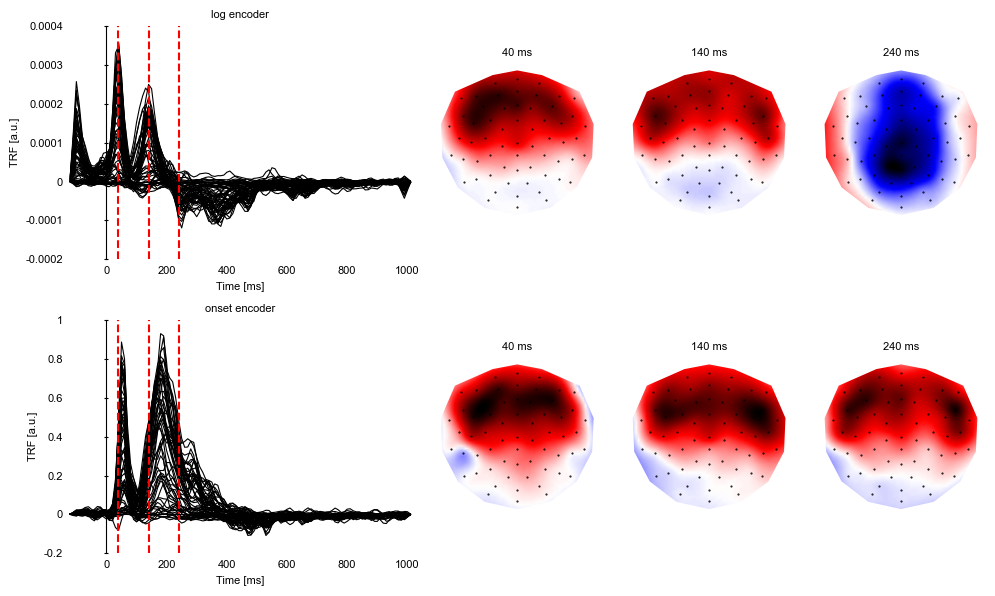

In [20]:

# --- Encoder TRFs ---
encoder_trfs = {
    'log': universal_encoder_log_trf,
    'onset': universal_encoder_onset_trf
}

fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[2, 1, 1, 1])  # 2 rows, 4 columns; first column wider for butterfly

for row, trf_type in enumerate(['log', 'onset']):
    trf = encoder_trfs[trf_type]

    # Butterfly plot (first column)
    ax_butterfly = fig.add_subplot(gs[row, 0])
    eelbrain.plot.Butterfly(trf, axes=ax_butterfly,
                            linewidth=0.8, color='k', ylabel='TRF [a.u.]', frame='t')
    for t in times:
        ax_butterfly.axvline(t, color='r', linestyle='--')
    ax_butterfly.set_title(f'{trf_type} encoder')

    # Topomap plots (remaining columns)
    for col, t in enumerate(times):
        ax_topo = fig.add_subplot(gs[row, col+1])
        topo_trf = trf.sub(time=t)
        eelbrain.plot.Topomap(topo_trf, axes=ax_topo,
                              axtitle=f"{int(t*1000)} ms", vmax=None)

plt.tight_layout()
plt.show()